목차
---

- 시계열 데이터란?
    - 시계열 데이터의 정의
    - 시계열 데이터의 특성
    - 시계열 데이터의 분석요인
- 시계열 데이터 전처리
    - 결측치/이상치 처리
    - EDA
    - 요소분해
        - 가법모형 / 승법모형
        - seasonal_decompose / STL
- 정상성 판단
    - 정상성의 정의 / 강한 정상성과 약한 정상성
    - 정상성의 판단 - 시각 / 통계
    - 정상성 확보 방법
- 단변량 시계열 분석
    - 안정적 시계열 분석
        - AR / MA
        - AR,MA의 전제조건
        - ARMA
        - 차수 결정 방법 : 자기 상관 함수 (ACF, PACF)
    - 불안정 시계열 분석
        - ARIMA / SARIMA
- 다변량 시계열 분석
    - VAR
- 딥러닝을 활용한 시계열 분석
    - RNN / Tranformer / Foundation Model

# 시계열!!!!!!!
## 1. 시계열 데이터란?
---
### 1-1 시계열 데이터의 정의

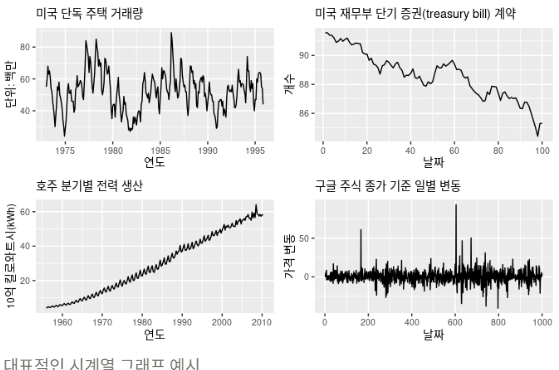  
- 한 대상을 시간의 흐름에 따라 수집한 d (d=데이터 약어)
- 연속된 관측치는 서로 상관관계가 존재. 순서가 중요한 **시퀀스 d**로 간주됨 (시퀀스 d. 순차적 d랑 같은말이네 외우지말자)
- 단순 시간-수치로 이루어진 d뿐만아니라 단어의 순서가 중요한 NLP(natural language processing)데이터  
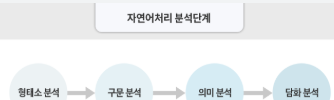  
### - 핵심 질문: 과거 데이터가 미래에 어떤 영향을 미치는가?

- 활용 분야
    - 의학:
        - 심전도 모니터링(심장이 이렇게 뛰고 있으면 곧 죽는다는 신호라던가),
        - 뇌전도 모니터링(똑같을듯)
    - 경제학: 
        - 주가 및 거래량 데이터(100만원에 20원 버는 모델 생각난다),
        - 이자율 데이터(ㅈㅁㄴㅇ: 이자율은 무작위로 움직이는 것처럼 보이지만, 국가의 통화 정책, 물가 상승률(인플레이션), 경기 순환 주기와 밀접한 연반성을 가집),
        - 분기별 매출 데이터
             - **계절성**: 매출 데이터는 일정한 주기적 패턴을 가짐/ 에어컨은 2-3분기-4~6+7~9월에, 유통업체는 연말 포함된 4분기에 매출 급등
            - SARIMA, Autoformer 딥러닝 모델이잇다. 이를 바탕으로 *원자재 구매*, *생산 계획*, *마케팅 예산* 등을 수립
        - 이상치 탐지: 특정 분기에 매출이 폭락하거나 급등했다면, 일시적 노이즈(*불규칙 요인*)인지 경쟁사 등장 등의 구조적 변화(추세 변화)인지 감지하여 감지.
        - 업계 예측 데이터 (industry forecasting)
            - 장기 수요 예측: 대규모 설비 투자 필요한 자동차, 반도체, 에너지 산업에서는 향후 수년 동안의 업계 수요 시계열 d 예측하여 *공장 증설 여부*를 예측 (TFT나 Informer 모델)
            - 외생 변수(external factors): 단순 과거 수치만 보지 x
                - 날씨, 규제 변화, 인구 구조 변동, 글로벌 공급망 트렌드 등 다양한 외부 변수 고려.여러 변수가 복합적으로 작용하는 *다변량 시계열 분석*(여러 숫자가 동시에 시간에 따라 변하는)

---

### 단변량 시계열, 다변량 시계열

#### 1. 단변량 시계열: 하나의 숫자가 시간에 따라 변하는 것
- 시간에 따라 연속적으로 측정된 **단일 변수**
- 시간의 흐름에 따른 패턴과 TREND 이해
- 적용 사례: 주식 가격, 온도, 매출 d

### 2. 다변량 시계열: 여러 숫자가 동시에 시간에 따라 변하는 것
- 같은 시간에 기록된 *둘 이상의 x*
- x간 상호작용 및 영향력 파악(헐...코드 어떡해)
- ex) 경제 지표, 기후 모델

    - 단변량; 오늘 내 몸무게만 맨날재기
    - 다변량: 몸무게, 칼로리 섭튀량, 운동시간 다 재는거

### 시계열 분석과 목적

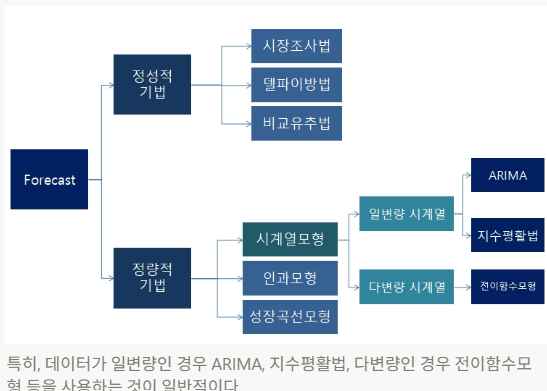


**시계열 분석의 활용 방안**  
- 웹 트래픽 예측을 통한 서버 최적화
- 주가, 환율, 금리 등의 변동 예측
- 환자의 생체신호 데이터(심박수, 혈당 등) 분석을 통한 이상 탐지 및 건강상태 예측
- 사용자의 앱 사용 로그를 이용한 사용자 이탈 예측
- 유튜버의 조회수 시계열 데이터를 통해 팬덤 이탈 신호를 볼 수도 있겠다


### 1.2 시계열 데이터의 특징

#### ① 시간의존성 (Temporal Dependence)   
시계열 데이터는 시간 순서에 따라 관측되므로 데이터의 순서를 바꾸면 의미가 달라짐  
#### ② 계절성 (Seasonality) & 추세 (Trend)  
시간에 따라 장기적으로 증가/감소하는 추세 + 일정 주기로 반복되는 패턴  
- 계절성: 일정 주기 (일, 주, 월, 년 등)에 따라 반복적으로 나타나는 데이터의 변동
- 추세 (트렌드!!!)

#### ③ 자기상관성 (Autocorrelation)
- = 이전 시점의 값이 이후 시점의 값에 영향을 미친다 
    - 한 시점의 값이 과거의 값과 통계적으로 관련 있는 성질 → 시간이 지남에 따라 값들 간에 일정한 패턴이나 반복이 존재한다는 것
    - 관측값들은 서로 독립적이지 않다
    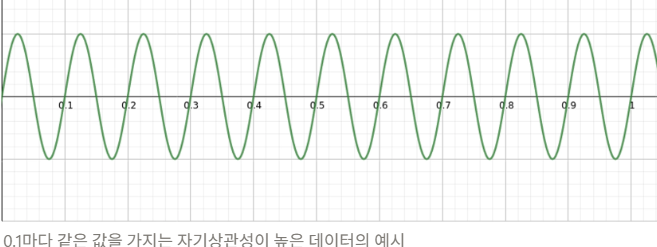  
    이건 대체 뭘까... 근데 심박수도 약간 이럴 듯

자기상관성을 파악하면 과거의 데이터를 바탕으로 미래를 예측 가능!

- 자기상관성 때문에 회귀분석 불가: 계열 데이터는 “오늘이 어제의 영향을 받는” 특성이 있음. 이에 일반 회귀분석을 사용하면 다음과 같은 세가지 문제 발생
    - 1. 오차항 독립성 가정 위반 → 통계 결과 왜곡
    - 2. 허위 상관관계 문제  
    ex) “대한민국 1인당 GDP” vs “A의 키 (0세~20세)”  
    두 변수 모두 시간이 지남에 따라 꾸준히 증가하는 추세(Trend)를 가진다.  
    이상태에서 OLS 회귀를 돌리면...
        - 상관계수는 매우 높게 측정
        - 실제로는 두 변수 간 인과관계 없음
        - 이런 경우를 “허위 상관관계 (Spurious Correlation)“라고 부름
        - 이것은 단지 공통된 시간 추세(트렌드)로인한것.
        - 해결방법: 추세 제거
        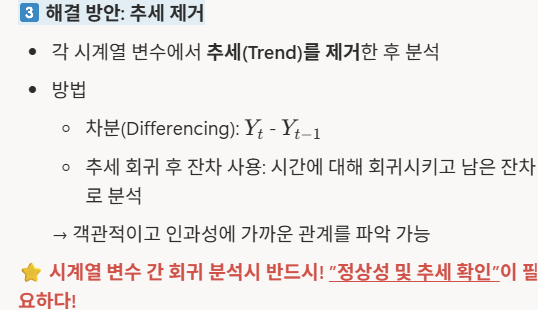  
        지금은 어떻게 하라는건지 모르겠음
    - 3. 예측의 어려움 & 모델 복잡성 증가
        - 단순 회귀 모델 XXXXX, AR, ARIMA 등의 시계열 모델로 대체 필요

### 1.3 시계열 데이터의 분석요인

#### ① 추세 요인 (Trend Factor)

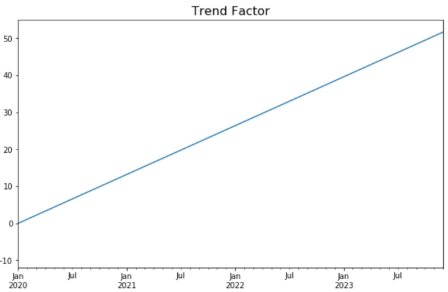

- 데이터 전반에 걸쳐 시간에 따라 지속적으로 증가/감소하는 경향
- 시각적 표현: 꾸준히 증가하거나 감소하는 선형 그래프
- ex. 연도별 매출 상승, 출산률 감소 등

#### ② 계절 요인 (Seasonal Factor)

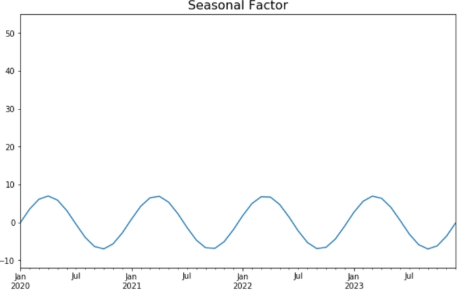


- 일정한 주기(계절, 월, 요일 등 정기적인 주기)로 반복되는 패턴
- 시각적 표현: 주기적인 변동을 나타내는 그래프
- ex. 크리스마스 시즌에 관련 용품 매출이 증가

#### ③ 순환 요인(Cycle Factor)

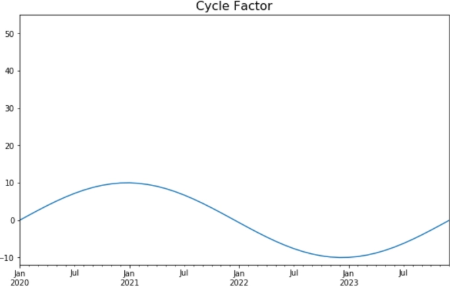

- 계절성보다 더 길고 불규칙한 주기로 반복되는 변동
- 시각적 표현: 길게 상승과 하강을 반복하는 파형 그래프

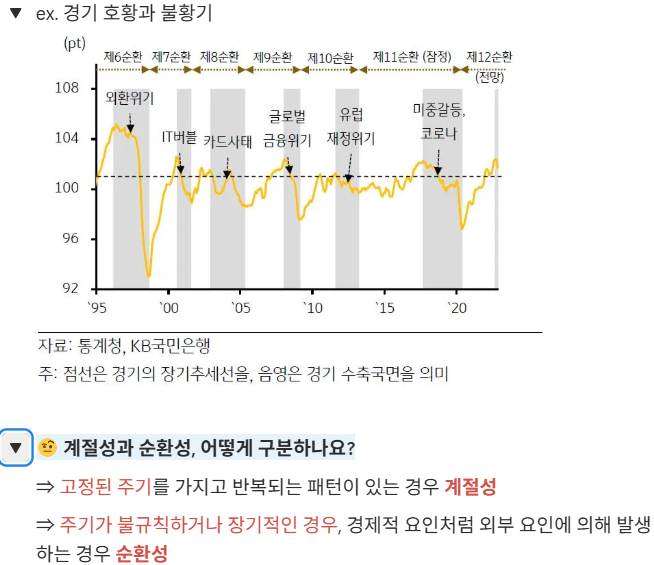

#### ④ 불규칙 요인(Irregular Factor) 

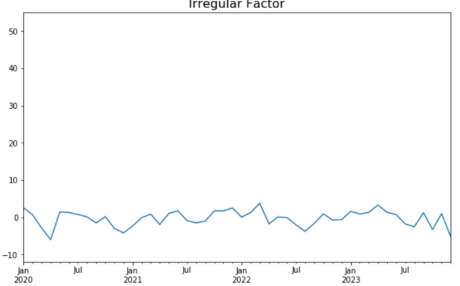

- 추세, 계절성, 순환성을 모두 제거한 뒤 남은 예측 불가능한 변동 
- 노이즈, 우연적 사건, 일시적인 변동, 이상치 등을 모두 포함
- 시각적 표현: 불규칙한 변동을 나타내는 그래프
- ex. 자연재해, 팬데믹

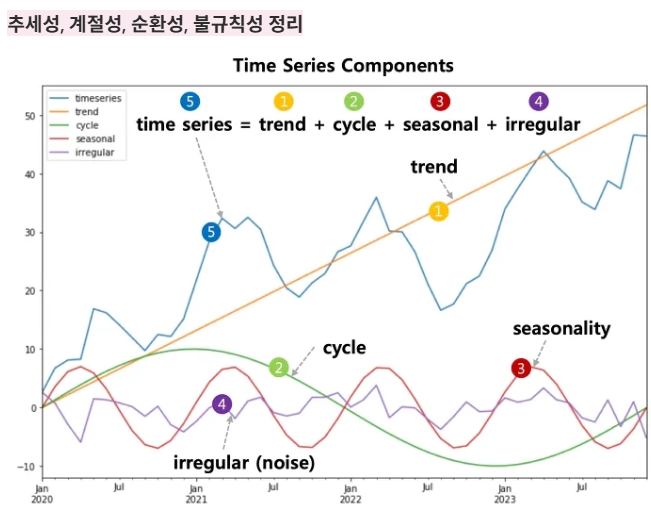

### 1.4 시계열 분석의 Work Flow

1. 데이터 전처리 - 결측치 보간, 이상치 제거, 요소분해
2. 정상성 판단 
3. 모델링 및 예측 

## 2. 시계열 데이터 전처리

시계열 데이터의 특성(시간 의존성/추세&계절성/자기상관성)이 존재! 이러한 특성이 왜곡되지 않도록 시계열 특성을 반영한 전처리가 필요

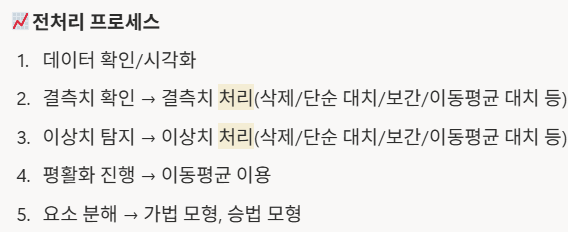

### 2.1 결측치/이상치 탐지 및 처리

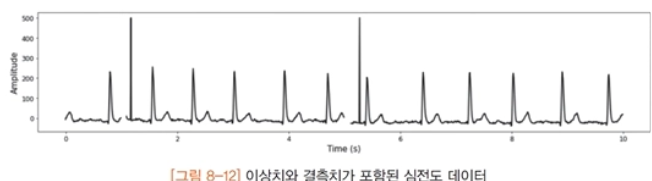

#### a. 시계열 데이터의 결측치

- 특정 시점(time point)에서 값이 측정되지 않았거나 **누락된 상태**
- 센서 오류·수집 누락·전송 지연 등으로 발생
- 결측치가 존재하면 **추세·계절성이 왜곡**되므로 적절한 대치와 보간이 필요

##### 결측치 처리 방법
- 단순 삭제 vs 단순 대치
    - 삭제
        - 비어 있는 시점의 데이터를 제거.
        - 시간 흐름의 연속성이 깨지고, 분석 구간이 짧아질 수 있음
    - 단순 대치
        - 평균, 중앙값, 최빈값, 0으로 결측치 채움
        - 패턴 왜곡 가능성 큼
- 보간법
    - 주어진 데이터 포인트의 값을 사용하여 두 개 이상의 데이터 포인트 사이에서 누락된 값을 추정하는 수학적 기법  
    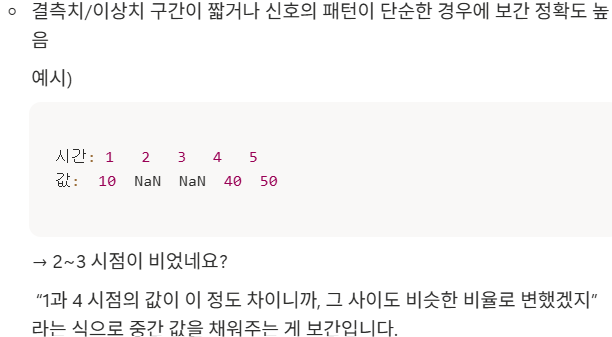
    - 선형, 다항식, 스플라인, 조각별 상수 보간법이 있음..

#### b. 시계열 데이터의 이상치 
- 측정된 값이 일반적이지 않은 경우
- 단순히 이상한 값이 아니라 신호의 중요한 의미일 수 있음!!!!
- 이상치 탐지 방법
    - CART도 이상치를 탐지하는 데 쓰이는군.

##### 이상치 처리 방법
- 이상치를 결측치로 간주->결측치처럼 처리
- 삭제, 단순 대치, 보간

### 2.2 EDA (평활화)  
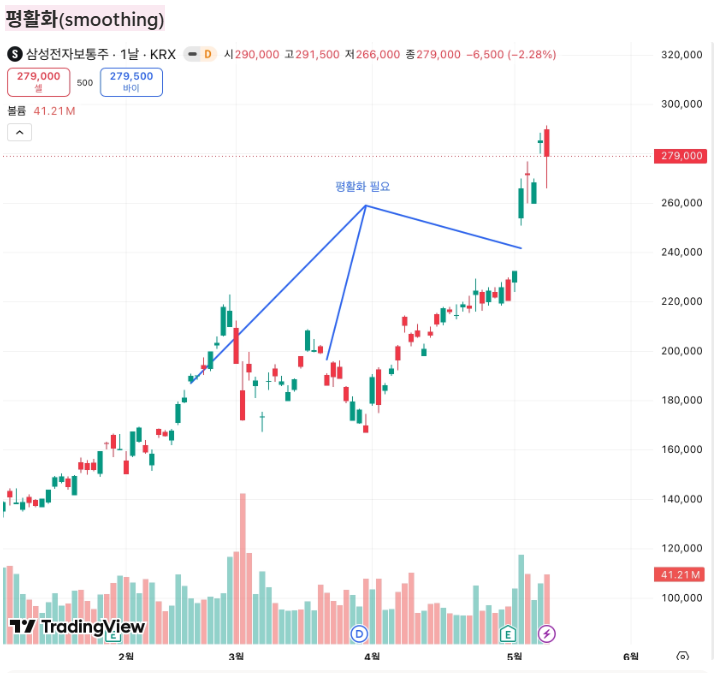  
주식을 해야겠다

- 뜻: 시계열 데이터에서 노이즈를 줄이고, 전체적인 흐름이나 추세를  더 명확하게 파악하기 위해 데이터를 부드럽게 만드는 기술
- 원래 데이터 안에 자연스럽게 섞여 있는 설명 불가능한 랜덤 변동(오차)
    - 우리가 관측한 데이터 = 신호(signal) + 노이즈(noise)
    - 헐...

##### 이동평균(MA, moving average)

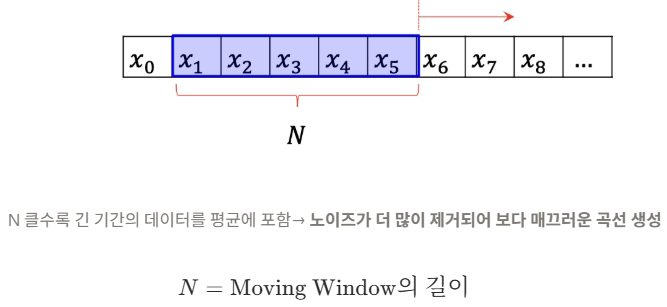

- 윈도우 길이에 따른변화 
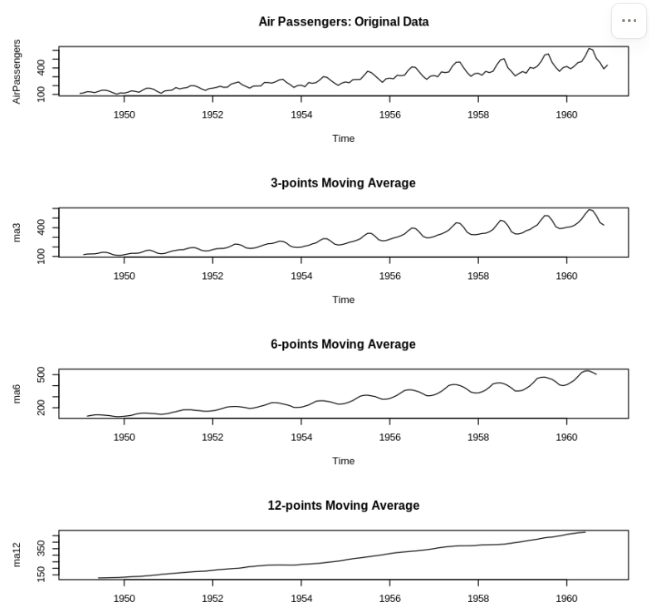

- 시계열의 부분집합으로 평균을 구하여 평활화 효과를 얻는 방법
- 윈도우(평균을 구할 구간의 크기) 내의 평균을 구하는 방법

- 시계열의 부분집합으로 평균을 구하여 평활화 효과를 얻는 방법
- 윈도우(평균을 구할 구간의 크기) 내의 평균을 구하는 방법

- 사용 목적
    - 노이즈 제거: 일시적인 급등/급락을 평탄화
    - 추세 파악: 상승/하강 흐름을 쉽게 식별
    - 예측의 기초자료: 시계열 예측(ARIMA 등)의 기반이 되기도 함

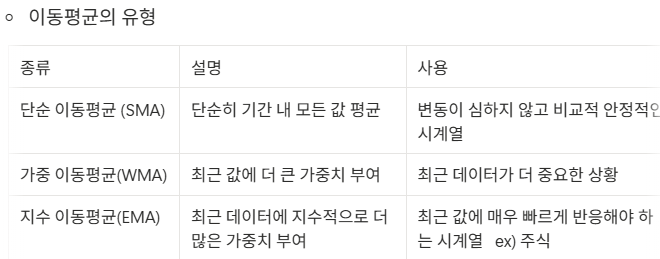

### 2.3 요소분해 (Decomposition, 시계열 분해)

- 주어진 시계열 데이터를 개별 성분(추세성, 계절성, 순환성, 불규칙성)으로 분해하는 과정

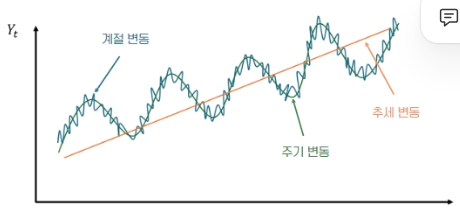

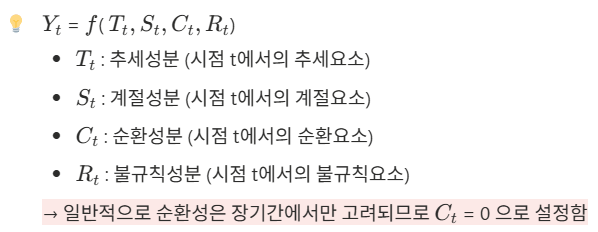

- 요소분해를 하는 이유
    - 시계열 데이터 = 추세/계절성/순환성/불규칙성 등 다양한 변동이 결합된 형태임
    - 각 요소를 분리하면 각각의 패턴을 명확히 이해 가능
    - 이후 예측, 이상 탐지 등 분석 작업을 정교하게 수행할 수 있음

가법모형: 각 변동 요인들이 독립적으로 더해지며, 모든 요소의 영향이 일정함  
승법모형: 추세가 커질수록 계절성이나 불규칙성의 효과도 비례해서 커짐  

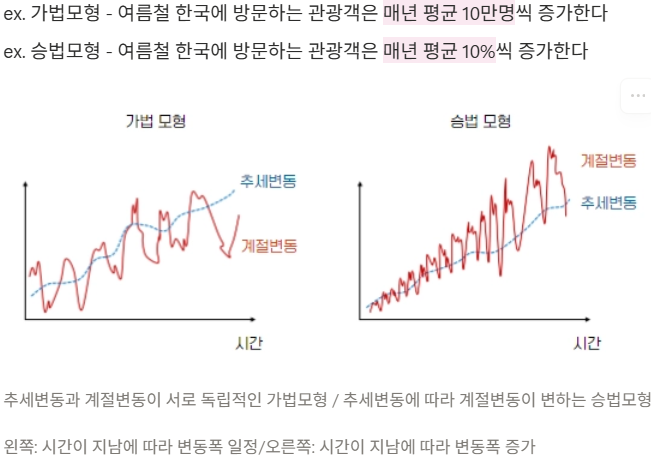  
오우 단어 어려운데 입에 붙여야겠당

##### 분해 방법(구현 알고리즘)

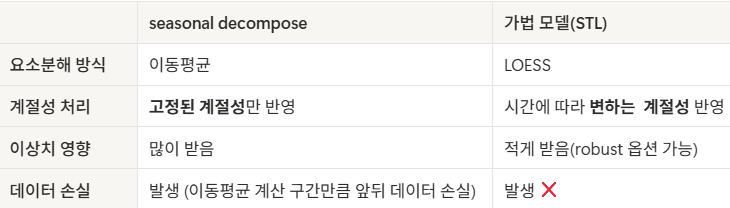

#### ① seasonal_decompose - MA 기반 분해
- 전통적인 시계열 분해 기법, 이동 평균을 통해 추세를 추출한 뒤 잔여 성분에서 계절성을 분리하는 방식

#### ② STL - LOESS 기반 분해
- 이동평균 대신 LOESS(Locally Estimated Scatterplot Smoothing)를 사용한다. 추세와 계절성이 시간에 따라 변화하는 경우에도 유연하게 포착할 수 있으며, 이상치에 강건한 분해가 가능


## 3. 정상성 판단
### 3.1 정상성이란?

#### 정상성의 핵심: '시간에 상관없이' 일정한 성질을 띠고 있다!

#### 정상성 : 시계열 데이터의 평균, 분산 등 통계적 특성이 시간에 따라 일정한 수준으로 유지되는 것

정상성 시계열, 비정상 시계열

- 통계 분석에서 정상성이 중요한 이유
- 예측이 가능하다 → 과거의 패턴과 성질이 미래에도 똑같이 유지 될것이라 가정할 수 있기 때문에 통계모델링에 바로 적용하기 좋음

### 3.2 강한 정상성과 약한 정상성
- 강한 정상성: 완벽하지만 비현실적인 기준
- 개념: 시간을 언제로 잡든, 데이터의 확률 분포 자체가 똑같은 상태
- 특징: 평균, 분산 뿐만 아니라 데이터의 왜도, 첨도 등 모든 통계적 특성이 일정
- 한계: 현실의 데이터는 잡음과 외부 요인이 항상 존재하기 때문에, 이런 상태는 거의 존재하지 않음

- 약한 정상성: 실무에서 쓰는 현실적인 기준
- 평균이 일정: 시간이 지나도 일정한 수준을 유지
- 분산이 일정: 데이터의 오르내림 변동 폭이 일정한 수준을 유지
- 자기공분산이 시차에만 의존: 데이터 간의 관계가 특정 시점이 아니라 시간의 간격에 의해서만 결정
- **우리에게 필요한 데이터는 약한 정상성을 띄는 데이터!**

### 3-3. 정상성 판단하기

정상성을 띄는 시계열 데이터는 그래프를 봤을 때, 일정한 기준선(평균)을 중심으로 일정한 폭으로 진동하는 형태를 보임

- 계절성이 있는 경우: 1년 등의 특정 주기로 패턴이 반복됨 (ex. 월별 아이스크림 판매량)

- 그렇다면 추세가 뚜렷한 시계열은 정상 시계열로 변환을 못하나요?
    - 차분(differecing)한 결과로 해석 가능
    - 주식 가격 자체는 비정상 시계열임
    - but! 오늘 가격에서 어제 가격을 뺀 일일변동량을 구하면 → 추세가 제거, 정상 시계열로 변환됨

- 대부분의 시계열 검정은 단위근(Unit Root)가 있는지를 확인하는 과정을 거친다.
    - 단위근 이란?
        - 과거 충격이 영구적으로 누적되는 특성을 의미 - 대표적인 비정상성의 원인으로 존재한다. 
        - 시계열이 Random하게 움직이게 만들어 평균으로 회귀하지 않고, 분산이 시간에 따라 증가하며 예측이 어려워짐.

#### 단위근 검정법

ADF vs KPSS

- ADF(Augmented Dickey-Fuller) 검정
- 단위근의 존재 여부를 검정하여 시계열의 정상성을 판단하는 방법이다. "이 시계열이 비정상이 아님을 증명하자" 는 관점에서 출발
    - 귀무가설 : 단위근이 존재한다 → 비정상 시계열
    - 대립가설 : 단위근이 존재하지 않는다 → 정상 시계열
- ADF는 시계열이 과거 값에 얼마나 의존하는지를 측정
- 과거 값의 영향이 시간이 지남에 따라 점점 사라지면 정상 시계열, 누적되어 사라지지 않으면 단위근이 존재하는 비정상 시계열로 판단

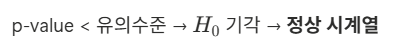

- KPSS 검정
- ADF와 반대로 "이 시계열이 정상임을 반증하자" 는 관점에서 출발하는 검정
- ADF의 검정력이 낮다는 한계를 보완하기 위해 함께 사용
    - 귀무가설 : 단위근이 존재하지 않는다 → 정상 시계열
    - 대립가설 : 단위근이 존재한다 → 비정상 시계열
- KPSS는 시계열이 일정한 평균 수준을 유지하는지를 측정
- 평균이 시간에 따라 흔들리지 않으면 정상, 평균 자체가 계속 변하고 있으면 비정상으로 판단

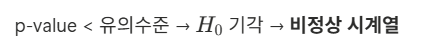

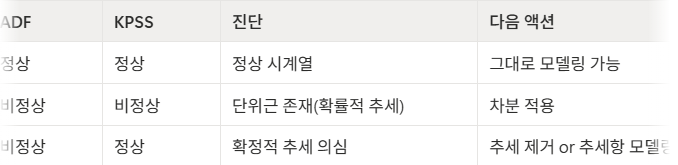

### 3.4 정상성 확보를 위한 여러가지 방법들

#### #1 추세 제거  
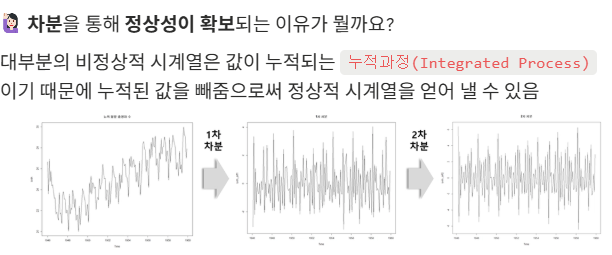

#### #2 계절성 제거  
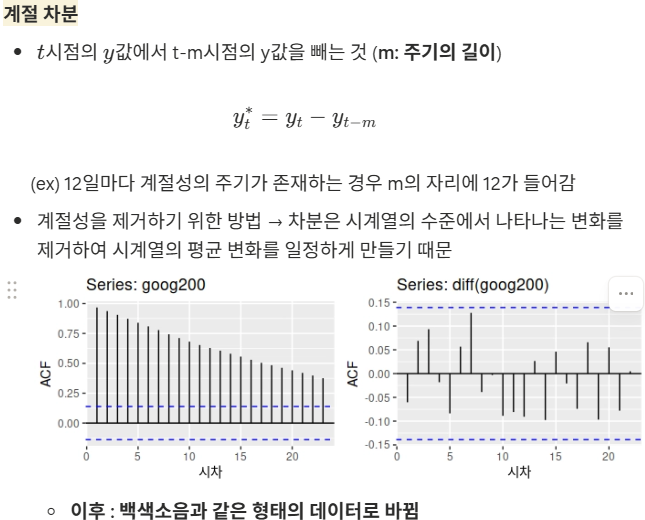  
- 데이터에 계절성 패턴이 강하게 나타나면, 계절성 차분을 먼저 계산하는 것이 좋음. 계절성 차분을 한 이후에 시계열에서 정상성이 나타나기도 하기 때문에 이런 경우에는 1차 차분을 구할 필요가 없게 되기 때문임. 1차 차분을 먼저 계산했다면, 여전히 남아있는 계절성이 나타날 것임

#### #3 분산 안정화  
: 시계열의 변동 폭이 점점 커지거나 작아질 때 적용  
로그변환: 분산의 정상성 확보하기 위한 방법  

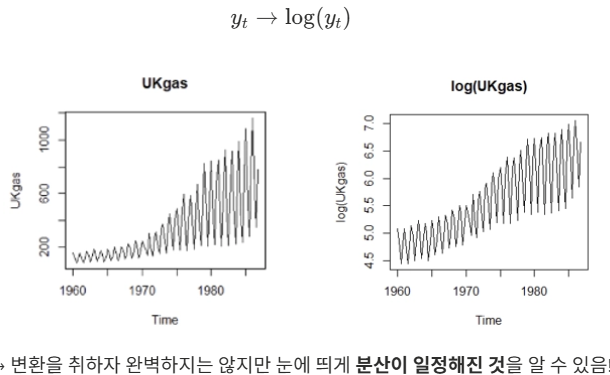




## 4. 단변량 시계열 분석

### 4.1 안정적 시계열 분석

#### ① 자기 회귀 모델 (Autoregressive Model, AR)

- 자기 회귀: ​과거의 ‘자기 자신 데이터(순위)’가 미래 값을 설명해줄 것이라고 가정하는 것

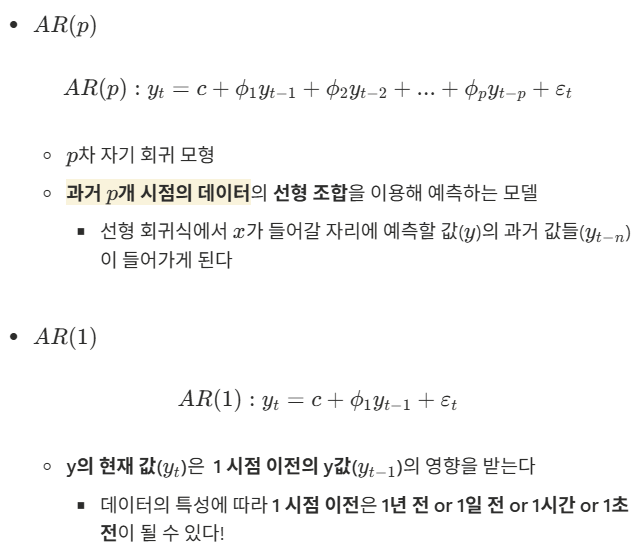

#### ② 이동 평균 모델 (Moving Average , MA)

- 이동 평균 모델이란, 과거 시점의 잔차를 독립변수로 삼아 현재 값을 예측하는 모델  
→ 과거의 잘못 예측한 것(예측 오차, 충격)을 현재 시점에 반영

- 잔차= 실제 값과 예측 값의 차이
- 잔차들은 모두 백색잡음 & 서로 독립적

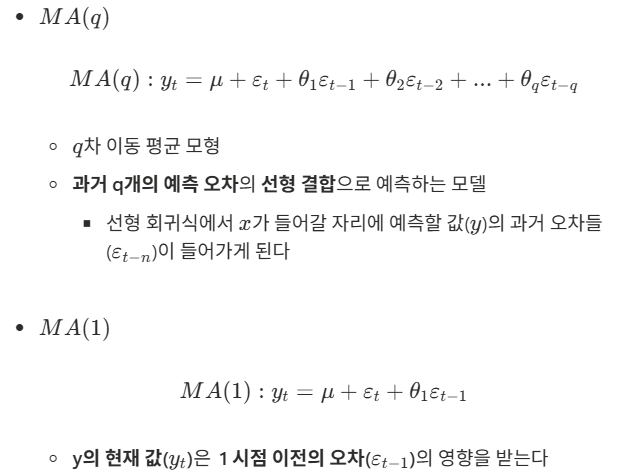

#### ③ AR, MA 모델의 전제 조건

- AR 모형의 정상성 조건
    - 모든 해(z)의 절댓값 > 1 ⇒ AR의 정상성 확보

- MA 모형의 정상성 조건
- 잔차들은 이미 정상성 만족해서, 잔차들의 조합으로 이뤄진 MA 모델도 항상 정상성 만족!

##### 가역성
- MA 모형을 AR(∞) 형태로 재표현할 수 있는지 여부
- MA 모형에서는 현재 시점의 값을 과거 시점의 오차항으로 예측  
    → 문제 : 오차항은 직접 관찰이 불가능하다!

- 오차항도 관측 가능한 과거값으로 표현할 수 있어야 안정적!

#### ④ ARMA (Autoregressive Moving Average) 모형

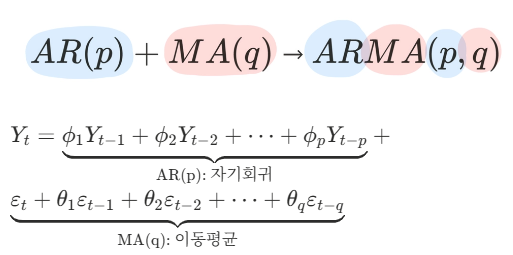  
뭔가 묘하게 내적생각남왠지는모름

#### ⑤ 차수 결정 방법: 자기 상관 함수
- 두 그래프를 통해 현재 값이 과거 값과 어떤 관계가 있는지 파악하고 이를 통해 AR, MA, ARMA의 적절한 차수(p, q)를 결정

    -  자기 상관 계수 (Auto Correlation Function, ACF)
        - ARMA(p, q)모형에서 사용할 q개의 오차 결정 방법
        - 두 시점 사이의 상관 관계 파악 (간접 영향까지 모두 파악)

    - 부분 자기 상관 계수 (Partial Autocorrelation Function, PACF)
        - ARMA(p, q) 모형에서 사용할 p개의 시점 결정 방법
        - 두 시점 사이의 직접적인 영향만 파악

### 4.2 불안정 시계열 분석

- 불안정 시계열 모델은 안정적 시계열 모델(ARMA)에 정상성 확보 과정(차분, 계절성 차분)이 추가된 형태!

#### ① ARIMA (Autoregressive Integrated Moving Average)

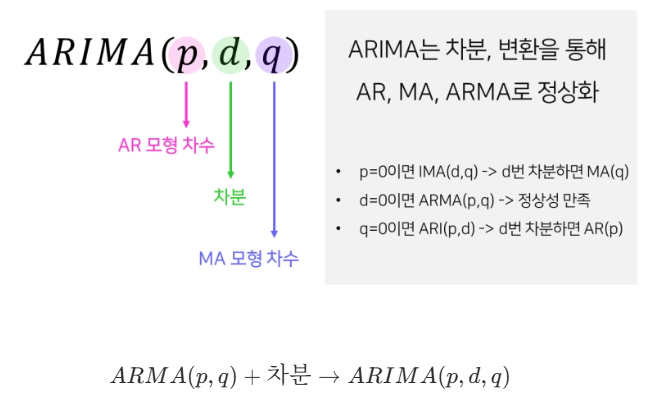

- ARIMA 모형의 특수한 경우

| 1. 백색잡음 | ARIMA(0,0,0) |
| --- | --- |
| 2. 자기회귀 | ARIMA(p,0,0) ⇔ AR(p) |
| 3. 이동평균 | ARIMA(0, 0, q) ⇔ MA(q) |
| 4. 랜덤워크 | 상수가 없는 ARIMA(0,1,0) |
| 5. 표류를 포함하는 랜덤워크 | 상수가 있는 ARIMA(0,1,0) |

#### ② SARIMA (Seasonal ARIMA)

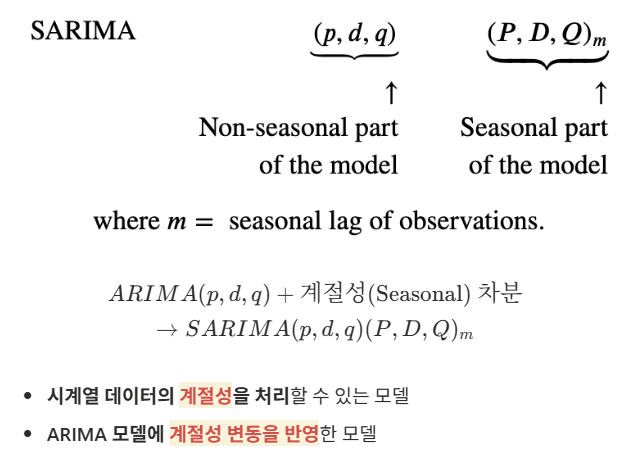

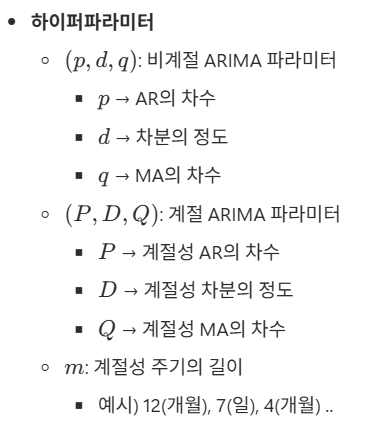



## 5. 다변량 시계열 분석

### VAR(Vector Autoregression)

핵심 아이디어: 자신의 과거 값과 다른 변수들의 과거 값을 함께 사용하여 미래를 예측하는 모델

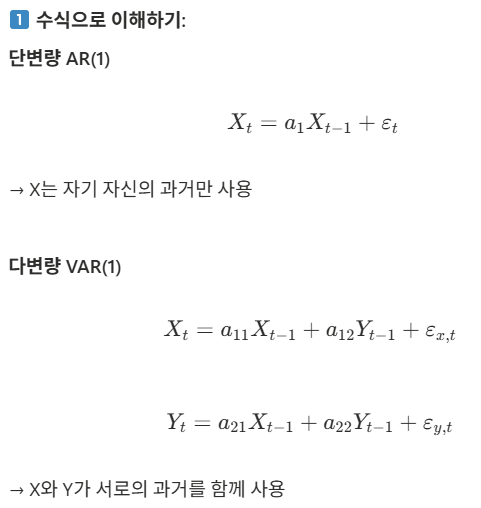

##### 어떤 경우에 추천?

**적합한 경우:**

- 변수들이 서로 영향을 주고받는 경우
- 경제·금융 지표처럼 상호 의존성이 중요한 경우

**부적합한 경우:**

- 변수가 너무 많은 경우 (파라미터 폭발)
- 변수 간 관계가 명확하지 않은 경우
- 장기 예측이 필요한 경우

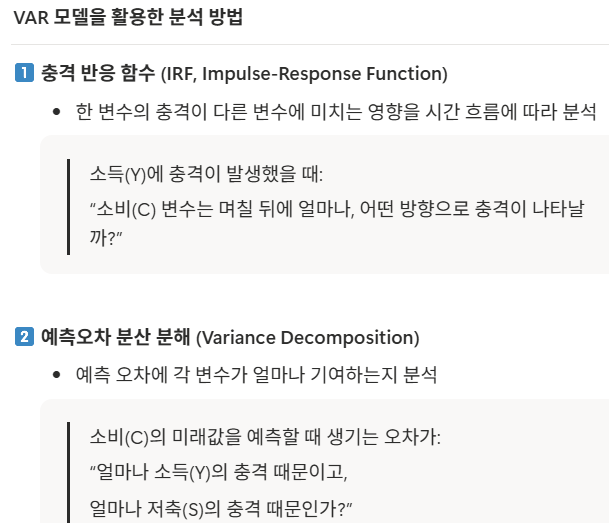



## 6. 딥러닝을 활용한 시계열 분석

### ⓪ 등장 배경

#### 전통 통계 모델의 한계

1. 데이터가 많으면 처리 속도가 느려짐
2. 크기가 고정된 데이터만 가능
3. 비선형 패턴 포착이 어려움

⇒ 딥러닝을 통해 해결

#### ① 순환 신경망 (RNN 계열)


- 적합한 경우:
    - 순차적 패턴이 중요한 시계열 데이터
    - 과거 정보가 미래 예측에 영향을 주는 문제
    - 시계열 길이와 목적에 따라 모델 선택 가능

- 부적합한 경우:
    - 매우 긴 시계열(수천~수만 step)에서는 학습이 어려울 수 있음
    - 병렬 처리 효율이 낮음
    - Transformer 계열 대비 학습 속도가 느린 편

#### ② Transformer 계열
- Informer (장기 예측 특화)
    - 특징 : 불필요한 연산을 줄여 계산 복잡도를 대폭 낮춘 모델
    - 실무 강점 : 매우 긴 시계열 데이터 처리에 강력함
- Autoformer (주기성 포착 특화)
    - 특징 : 시계열의 전통적 기법인 '요소 분해(추세/계절성)' 개념을 딥러닝 구조에 직접 결합한 모델
    - 실무 강점 : 연간 계절성 등 주기 패턴이 뚜렷하게 나타나는 판매량 예측에 압도적인 성능을 보임
- TFT (Temporal Fusion Transformer - 실무 활용도 1위)
    - 특징 : 과거 데이터뿐만 아니라 다양한 외부 변수(날씨, 휴일 유무 등)를 섞어서 예측할 수 있는 다목적 아키텍처
    - 실무 강점 : 어떤 변수가 예측에 가장 중요했는지 어텐션 스코어를 통한 해석이 가능해, 설명력이 - 중요한 유통/비즈니스 수요 예측에 가장 많이 쓰임

#### ③ Foundation Model
- 거대한 데이터로 사전 학습하여 다양한 문제를 해결할 수 있는 범용 모델
- 특징
    - 특정 문제 전용 XX
    - 범용적(Generalized) 
    - 사전 학습 후 Fine-tuning으로 특화

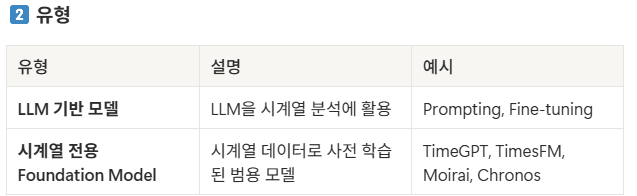

##### LLM 기반 모델 활용 방식
- **Without Adaptation**
    - LLM이 이미 시계열 지식을 가지고 있다고 가정
    - **프롬프트 엔지니어링**에 집중
- **Adapt LLM**
    - LLM을 **시계열 데이터로 Fine-tuning**
- **Adapt to LLM**
    - 시계열을 **텍스트로 변환** 후 LLM 활용
    - 예: 숫자 시계열 → “값이 증가 추세”, “주기성 있음” 등 텍스트화
